In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.utils import build_covariance_matrix
from neural_network.trainer import GeneralTrainer
from neural_network.config import MarketParams, ModelConfig
from neural_network.payoff import PutProductMultipleAssets

In [2]:
n_assets = 3

S0 = 2.0
r = 0.1

stds = np.array([0.4, 0.5, 0.6])
correlation_matrix = np.array([
    [1.0, 0.6, 0.3],
    [0.6, 1.0, 0.5],
    [0.3, 0.5, 1.0]
])

sigma = build_covariance_matrix(stds, correlation_matrix)

K = 4.0
T = 1.0
S_min = 0.0
S_max = (3 * K)**(1/3)

market_params = MarketParams(n_assets=3, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [3]:
input_size = n_assets + 1
hidden_sizes = [32, 64, 32]
output_size = 1
activation = nn.ReLU()
learning_rate = 0.001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

In [4]:
put_product = PutProductMultipleAssets()
trainer_product = GeneralTrainer(model_config, market_params, put_product, 67)
trainer_product.train(num_samples=1000, max_iterations=10000, tol=1e-4)

Iteration 0, Loss: 49.69623947143555
Iteration 100, Loss: 1.622111201286316
Iteration 200, Loss: 0.44593101739883423
Converged at iteration 230


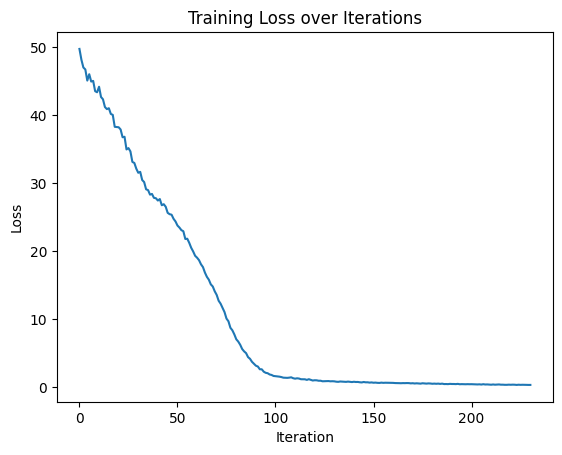

In [5]:
trainer_product.plot_losses()

In [6]:
trainer_product.predict(1, 5, 5).item()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x3 and 4x32)